In [1]:
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import KDTree
import xarray as xr
from MHW_funcs import get_oisst_flag, get_oisst_flag_spatialONLY
from MHW_funcs import map_study_region
import matplotlib.pyplot as plt
import matplotlib.colors as mpcolors
from cmocean import cm as cmo
from cartopy import crs as ccrs
from cartopy import feature as cfeature 
import matplotlib.ticker as ticker
import boto3


BOLD = "\033[1m"
RESET = "\033[0m"
RED = "\033[31m"
LINE = "\033[4m"

## 1. Grab data
### 1.1. Select MHW

In [2]:
# Path to Crocolake
parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'

# path to heatwave csv
csv_path = '/home/jovyan/Marine-Heat-Waves/MHW_list.csv'

# open heatwave database and format
dfhw = pd.read_csv(csv_path)
dfhw.set_index('name',inplace=True)
date_cols = ['date_start','date_end']
dfhw[date_cols] = dfhw[date_cols].apply(pd.to_datetime)

# print heatwave options
print(f"{BOLD}Select from the following:{RESET} \n" + ", ".join(f"{n}: {idx}" for n, idx in enumerate(dfhw.index, start=0)))

# Choose a HW
hw = "SWPac2023"

# Boundaries
lat0 = dfhw.loc[hw,'lat0'] 
lat1 = dfhw.loc[hw,'lat1'] 
lon0 = dfhw.loc[hw,'lon0'] 
lon1 = dfhw.loc[hw,'lon1'] 
z0 = 0
z1 = 500
date0 = dfhw.loc[hw,'date_start']
date1 = dfhw.loc[hw,'date_end']

Select from the following: 
0: Med2003, 1: Beng2001, 2: WA2011, 3: NWA2012, 4: WSA2014, 5: ECS2016, 6: AL2016, 7: NA2016, 8: NEP2015, 9: Tas2017, 10: Peru2017, 11: NA 2023, 12: SWPac2023


### 1.2. Get the data from the chosen MHW.

This method does deal with domains that cross 180<sup>o</sup> longitude.

In [3]:
# Setting up parquet schema
parquet_dir = '~/shared/go-bgc-2026/data/CrocoLake/BGC_ARGO/'
BGC_schema = pq.read_schema(parquet_dir+"_common_metadata")

# If lon crosses 180deg
if lon0 > lon1:
    # First half of meridional domain
    filters1 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<=",180),
                ("JULD",">",date0), ("JULD","<",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df1 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters1)
    df1 = df1.read().to_pandas()
    df1 = pd.read_parquet(parquet_dir, schema=BGC_schema, filters=filters1)

    # Second half of meridional domain
    filters2 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",-180), ("LONGITUDE","<=",lon1),
                ("JULD",">",date0), ("JULD","<",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df2 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters2)
    df2 = df2.read().to_pandas()

    # Combine domains
    df = pd.concat([df1, df2], ignore_index=True)

# If lon does NOT cross 180deg (normal case)
else:
    filters = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
                ("JULD",">",date0), ("JULD","<",date1),
                ("PRES","<",z1), #("PRES",">",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters)
    df = df.read().to_pandas()



In [4]:
N = 0
# list platform numbers and cycle numbers
for ID in df['PLATFORM_NUMBER'].unique():
    print(f"{BOLD}Float Number = {ID}{RESET}")
    float_df = df[df['PLATFORM_NUMBER'] == ID]
    float_df.reset_index(drop = True)
 
    print(f"--{LINE}Cycle Numbers = {np.array(float_df['CYCLE_NUMBER'].unique()).tolist()}{RESET}")
    N = N + len(float_df['CYCLE_NUMBER'].unique())

Float Number = 5905441
--Cycle Numbers = [144]
Float Number = 5905442
--Cycle Numbers = [141, 142]
Float Number = 5905501
--Cycle Numbers = [91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105]
Float Number = 5905505
--Cycle Numbers = [91, 92, 93, 99]
Float Number = 5905555
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Float Number = 5905556
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Float Number = 5905557
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Float Number = 5906623


--Cycle Numbers = [266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295]
Float Number = 5906624
--Cycle Numbers = [150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 163, 161, 162, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186]
Float Number = 5906635
--Cycle Numbers = [72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]
Float Number = 5905218
--Cycle Numbers = [180]
Float Number = 5906443
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
Float Number = 5906509
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8]
Float Number = 5906581
--Cycle Numbers = [1]
Float Number = 5906307


--Cycle Numbers = [90, 91, 92, 93, 94, 95, 101]
Float Number = 5906311
--Cycle Numbers = [68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108]
Float Number = 5906319
--Cycle Numbers = [68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Float Number = 5906444
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Float Number = 2903455
--Cycle Numbers = [1, 2, 3, 4, 5, 6]
Float Number = 2903456
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Float Number = 5906542
--Cycle Numbers = [1, 2, 3]
Float Number = 5906545
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Float Number = 590654

--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Float Number = 5906550
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Float Number = 5906551
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Float Number = 5906552
--Cycle Numbers = [1, 2, 3, 4, 5]
Float Number = 5906553
--Cycle Numbers = [1, 2, 3]
Float Number = 5906554
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Float Number = 5906555
--Cycle Numbers = [1]
Float Number = 5906567
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]


### 1.3. Select only the data you want

In [5]:
want_Oxygen = True
want_BBP = True
want_Turbidity = True
want_CP = True
want_Chla = True
want_CDOM = True
want_Nitrate = True
want_Bisulfide = True
want_pH = True
want_DownwellingIR = True
want_UpwellingIR = True
want_DownwellingPAR = True

In [6]:
base_info = ['PLATFORM_NUMBER', 'N_PROF', 'N_LEVELS', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD', 
             'PRES', 'TEMP', 'PSAL']
oxygen_info = ['DOXY_ADJUSTED', 'DOXY_ADJUSTED_QC', 'DOXY_ADJUSTED_ERROR']
bbp_info = ['BBP_ADJUSTED', 'BBP_ADJUSTED_QC', 'BBP_ADJUSTED_ERROR']
turbidity_info = ['TURBIDITY_ADJUSTED', 'TURBIDITY_ADJUSTED_QC', 'TURBIDITY_ADJUSTED_ERROR']
cp_info = ['CP_ADJUSTED', 'CP_ADJUSTED_QC', 'CP_ADJUSTED_ERROR']
chla_info = ['CHLA_ADJUSTED', 'CHLA_ADJUSTED_QC', 'CHLA_ADJUSTED_ERROR',
            'CHLA_FLUORESCENCE_ADJUSTED', 'CHLA_FLUORESCENCE_ADJUSTED_QC', 'CHLA_FLUORESCENCE_ADJUSTED_ERROR',
            ]
cdom_info = ['CDOM_ADJUSTED', 'CDOM_ADJUSTED_QC', 'CDOM_ADJUSTED_ERROR']
nitrate_info = ['NITRATE_ADJUSTED', 'NITRATE_ADJUSTED_QC', 'NITRATE_ADJUSTED_ERROR']
bisulfide_info = ['BISULFIDE_ADJUSTED', 'BISULFIDE_ADJUSTED_QC', 'BISULFIDE_ADJUSTED_ERROR']
ph_info = ['PH_IN_SITU_TOTAL_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED_QC', 'PH_IN_SITU_TOTAL_ADJUSTED_ERROR']
downirrad_info = ['DOWN_IRRADIANCE_ADJUSTED', 'DOWN_IRRADIANCE_ADJUSTED_QC', 'DOWN_IRRADIANCE_ADJUSTED_ERROR']
upirrad_info = ['UP_IRRADIANCE_ADJUSTED', 'UP_IRRADIANCE_ADJUSTED_QC', 'UP_IRRADIANCE_ADJUSTED_ERROR']
downpar_info = ['DOWNWELLING_PAR_ADJUSTED', 'DOWNWELLING_PAR_ADJUSTED_QC', 'DOWNWELLING_PAR_ADJUSTED_ERROR']

In [7]:
params = base_info

if want_Oxygen:
    params = params + oxygen_info
if want_BBP:
    params = params + bbp_info
if want_Turbidity:
    params = params + turbidity_info
if want_CP:
    params = params + cp_info
if want_Chla:
    params = params + chla_info
if want_CDOM:
    params = params + cdom_info
if want_Nitrate:
    params = params + nitrate_info
if want_Bisulfide:
    params = params + bisulfide_info
if want_pH:
    params = params + ph_info
if want_DownwellingIR:
    params = params + downirrad_info
if want_UpwellingIR:
    params = params + upirrad_info
if want_DownwellingPAR:
    params = params + downpar_info

print(f"You have selected the following parameters before QC: {params}")

df = df.loc[:,params]

You have selected the following parameters before QC: ['PLATFORM_NUMBER', 'N_PROF', 'N_LEVELS', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD', 'PRES', 'TEMP', 'PSAL', 'DOXY_ADJUSTED', 'DOXY_ADJUSTED_QC', 'DOXY_ADJUSTED_ERROR', 'BBP_ADJUSTED', 'BBP_ADJUSTED_QC', 'BBP_ADJUSTED_ERROR', 'TURBIDITY_ADJUSTED', 'TURBIDITY_ADJUSTED_QC', 'TURBIDITY_ADJUSTED_ERROR', 'CP_ADJUSTED', 'CP_ADJUSTED_QC', 'CP_ADJUSTED_ERROR', 'CHLA_ADJUSTED', 'CHLA_ADJUSTED_QC', 'CHLA_ADJUSTED_ERROR', 'CHLA_FLUORESCENCE_ADJUSTED', 'CHLA_FLUORESCENCE_ADJUSTED_QC', 'CHLA_FLUORESCENCE_ADJUSTED_ERROR', 'CDOM_ADJUSTED', 'CDOM_ADJUSTED_QC', 'CDOM_ADJUSTED_ERROR', 'NITRATE_ADJUSTED', 'NITRATE_ADJUSTED_QC', 'NITRATE_ADJUSTED_ERROR', 'BISULFIDE_ADJUSTED', 'BISULFIDE_ADJUSTED_QC', 'BISULFIDE_ADJUSTED_ERROR', 'PH_IN_SITU_TOTAL_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED_QC', 'PH_IN_SITU_TOTAL_ADJUSTED_ERROR', 'DOWN_IRRADIANCE_ADJUSTED', 'DOWN_IRRADIANCE_ADJUSTED_QC', 'DOWN_IRRADIANCE_ADJUSTED_ERROR', 'UP_IRRADIANCE_ADJUSTED', 'UP_IRR

### 1.4. Filter out bad data

#### [QC Flags](https://argo.ucsd.edu/data/how-to-use-argo-files/)
| QC flag | Meaning                                   | Real time comment                                                                                                                                                                                                                                                       | Delayed mode comment                                                                         |
|---------|-------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------|
| 0       | No QC performed                           | No QC performed                                                                                                                                                                                                                                                         | No QC performed                                                                              |
| 1       | Good data                                 | All real time QC tests passed                                                                                                                                                                                                                                           | The adjusted value is statistically consistent and a statistical error estimate is supplied. |
| 2       | Probably good data                        |                                                                                                                                                                                                                                                                         | Probably good                                                                                |
| 3       | Bad data that are potentially correctable | Test 15 or Test 16 or Test 17 failed and all other real-time QC  tests passed. These data are not to be used without scientific  correction. A flag ‘3’ may be assigned by an operator during additional  visual QC for bad data that may be corrected in delayed mode. | An adjustment has been applied, but the value may still be bad.                              |
| 4       | Bad data                                  | Data have failed one or more of the real-time QC tests, excluding  Test 16. A flag ‘4’ may be assigned by an operator during additional  visual QC for bad data that are not correctable.                                                                               | Bad data.  Not adjustable.                                                                   |
| 5       | Value changed                             | Value changed                                                                                                                                                                                                                                                           | Value changed                                                                                |
| 6       | Not currently used                        | Not currently used                                                                                                                                                                                                                                                      | Not currently used                                                                           |
| 7       | Not currently used                        | Not currently used                                                                                                                                                                                                                                                      | Not currently used                                                                           |
| 8       | Estimated                                 | Estimated value (interpolated, extrapolated or other estimation).                                                                                                                                                                                                       | Estimated value (interpolated, extrapolated or other estimation).                            |
| 9       | Missing value                             | Missing value                                                                                                                                                                                                                                                           | Missing value                                                                                |

In [8]:
qc_strings = [s for s in params if s.endswith("QC")]
bad_vals = [0,3,4,6,7,9]

In [9]:
for s in qc_strings:
    var = s.removesuffix("_QC")

    df.loc[df[s].isin(bad_vals), var] = np.nan

### 1.5. Some info on the data

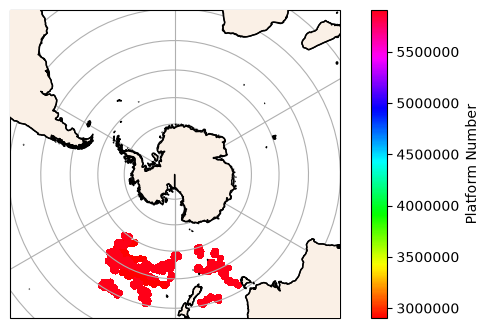

In [22]:
ax = map_study_region(ax_lims = [lon0, lon1, lat0, lat1+10], PROJ = ccrs.SouthPolarStereo())
im = ax.scatter(df['LONGITUDE'], df['LATITUDE'], 
                s = 10, c = df['PLATFORM_NUMBER'], cmap = 'hsv',
                transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, ax = ax)
cbar.ax.ticklabel_format(style='plain', axis='y')
cbar.set_label('Platform Number')

## 2. More data processing!
### 2.1. Adding month and year

In [11]:
df = df.assign(MONTH = [pd.Timestamp(ti).month for ti in df.loc[:,'JULD'].values])
df = df.assign(YEAR = [pd.Timestamp(ti).year for ti in df.loc[:,'JULD'].values])

### 2.2. Masking data for the MHW

[Function to flag data](https://github.com/go-bgc/Marine-Heat-Waves/blob/main/contributors/ellen/ellen_fxns.py) written by Ellen Park.

Mask of the North Atlantic 2023 heatwave created by Cassia Cai.

In [12]:
if hw == "NA 2023":
    mask_link = 's3://uw-escience-scratch-prod/oisst/mhw_mask_north_atlantic_final.zarr'
elif hw == "SWPac2023":
    mask_link = 's3://uw-escience-scratch-prod/oisst/mhw_mask_swp_final.zarr'

In [13]:
df_mhw = get_oisst_flag(df, oisst_path = mask_link)

Openining : s3://uw-escience-scratch-prod/oisst/mhw_mask_swp_final.zarr


0  out of 308


100  out of 308


200  out of 308


300  out of 308


In [14]:
df_mhw = df_mhw[df_mhw['mhw_mask'] == 1]

## 3. Make some preliminary plots
### 3.1. Temperature

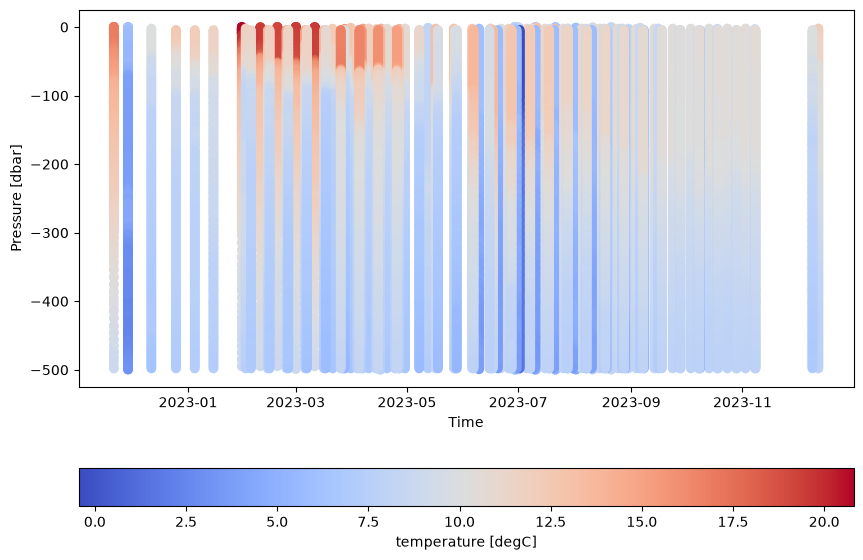

In [15]:
fig, ax = plt.subplots(figsize = [10,7])

x = df_mhw['JULD']
y = -df_mhw['PRES']
z = df_mhw['TEMP']

im = ax.scatter(x, y, c = z, cmap = 'coolwarm')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("temperature [degC]")

### 3.2. Oxygen

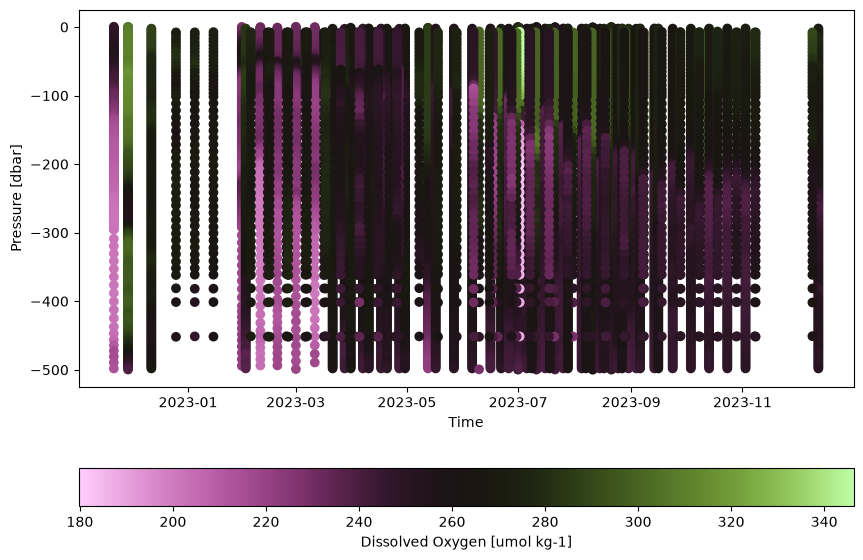

In [16]:
fig, ax = plt.subplots(figsize = [10,7])

x = df_mhw['JULD']
y = -df_mhw['PRES']
z = df_mhw['DOXY_ADJUSTED']

im = ax.scatter(x, y, c = z, cmap = 'vanimo')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("Dissolved Oxygen [umol kg-1]")

### 3.3. pH

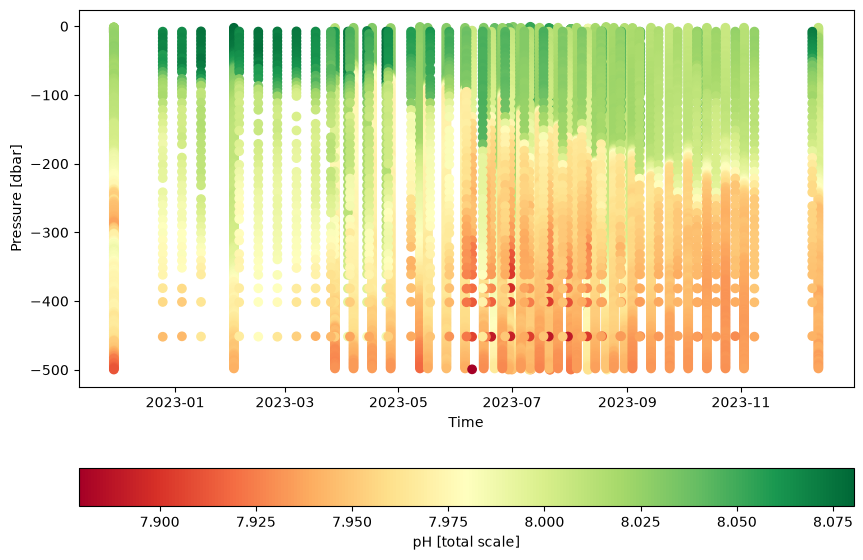

In [17]:
fig, ax = plt.subplots(figsize = [10,7])

x = df_mhw['JULD']
y = -df_mhw['PRES']
z = df_mhw['PH_IN_SITU_TOTAL_ADJUSTED']

im = ax.scatter(x, y, c = z, cmap = 'RdYlGn')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("pH [total scale]")

## 4. List out all the platforms and clcyes

In [18]:
N = 0
# list platform numbers and cycle numbers
for ID in df_mhw['PLATFORM_NUMBER'].unique():
    print(f"{BOLD}Float Number = {ID}{RESET}")
    float_df = df_mhw[df_mhw['PLATFORM_NUMBER'] == ID]
    float_df.reset_index(drop = True)

    KEYS = []
    for key in float_df.keys():
        if key.endswith("ADJUSTED"):
            if float_df[key].isna().all():
                KEYS.append(key)

    print(f"{RED}Included BGC variables: {KEYS}{RESET}")
 
    print(f"--{LINE}Cycle Numbers = {np.array(float_df['CYCLE_NUMBER'].unique()).tolist()}{RESET}")
    N = N + len(float_df['CYCLE_NUMBER'].unique())
        
        
        

Float Number = 5906623
Included BGC variables: ['BBP_ADJUSTED', 'TURBIDITY_ADJUSTED', 'CP_ADJUSTED', 'CHLA_FLUORESCENCE_ADJUSTED', 'CDOM_ADJUSTED', 'BISULFIDE_ADJUSTED', 'DOWN_IRRADIANCE_ADJUSTED', 'UP_IRRADIANCE_ADJUSTED', 'DOWNWELLING_PAR_ADJUSTED']
--Cycle Numbers = [274, 275, 276, 278, 279]
Float Number = 5906624
Included BGC variables: ['BBP_ADJUSTED', 'TURBIDITY_ADJUSTED', 'CP_ADJUSTED', 'CHLA_FLUORESCENCE_ADJUSTED', 'CDOM_ADJUSTED', 'BISULFIDE_ADJUSTED', 'DOWN_IRRADIANCE_ADJUSTED', 'UP_IRRADIANCE_ADJUSTED', 'DOWNWELLING_PAR_ADJUSTED']
--Cycle Numbers = [151, 170, 171, 172, 173]
Float Number = 5906635
Included BGC variables: ['BBP_ADJUSTED', 'TURBIDITY_ADJUSTED', 'CP_ADJUSTED', 'CHLA_FLUORESCENCE_ADJUSTED', 'CDOM_ADJUSTED', 'BISULFIDE_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED', 'DOWN_IRRADIANCE_ADJUSTED', 'UP_IRRADIANCE_ADJUSTED', 'DOWNWELLING_PAR_ADJUSTED']
--Cycle Numbers = [72, 79, 80, 81, 82, 83]
Float Number = 5906443
Included BGC variables: ['BBP_ADJUSTED', 'TURBIDITY_ADJUSTED'

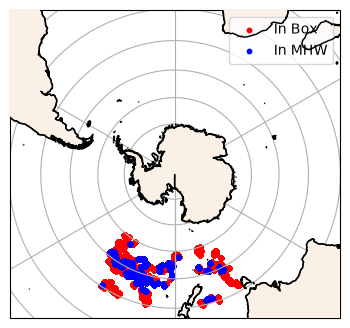

In [24]:
ax = map_study_region(ax_lims = [lon0, lon1, lat0, lat1+10], PROJ = ccrs.SouthPolarStereo())
im = ax.scatter(df['LONGITUDE'], df['LATITUDE'], 
                s = 10, c = 'red',
                transform=ccrs.PlateCarree(), 
                label = "In Box")
im = ax.scatter(df_mhw['LONGITUDE'], df_mhw['LATITUDE'], 
                s = 10, c = 'blue',
                transform=ccrs.PlateCarree(),
                label = "In MHW")
ax.legend()

## 5. Find float data in MHW spatial mask but outside of time bounds

Based on the same methodology used before to identify data in the heatwave. 
* Filter Crocolake data by the spatial bounds of the MHW.
* In 2 separate steps, further filter data by what occurs before the MHW and what occurs after MHW.
* Pick the parameters you're interested in. This is the same as what you selected for the MHW.
* Filter out bad data based on same contraints as before.
* Apply a mask that is spatial only. It takes out the time variable of the MHW mask and collapses the spatial coords to a 2D grid.

In [35]:
# ******************************
# BEFORE MHW
# ******************************

# If lon crosses 180deg
if lon0 > lon1:
    # First half of meridional domain
    filters1 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<=",180),
                ("JULD","<",date0), #("JULD",">",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df1 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters1)
    df1 = df1.read().to_pandas()
    df1 = pd.read_parquet(parquet_dir, schema=BGC_schema, filters=filters1)

    # Second half of meridional domain
    filters2 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",-180), ("LONGITUDE","<=",lon1),
                ("JULD","<",date0), #("JULD",">",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df2 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters2)
    df2 = df2.read().to_pandas()

    # Combine domains
    df_clim_before = pd.concat([df1, df2], ignore_index=True)

# If lon does NOT cross 180deg (normal case)
else:
    filters = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
                ("JULD","<",date0), #("JULD",">",date1),
                ("PRES","<",z1), #("PRES",">",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df_clim = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters)
    df_clim_before = df_clim.read().to_pandas()

# ******************************
# AFTER MHW
# ******************************

# If lon crosses 180deg
if lon0 > lon1:
    # First half of meridional domain
    filters1 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<=",180),
                ("JULD",">",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df1 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters1)
    df1 = df1.read().to_pandas()
    df1 = pd.read_parquet(parquet_dir, schema=BGC_schema, filters=filters1)

    # Second half of meridional domain
    filters2 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",-180), ("LONGITUDE","<=",lon1),
                ("JULD",">",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df2 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters2)
    df2 = df2.read().to_pandas()

    # Combine domains
    df_clim_after = pd.concat([df1, df2], ignore_index=True)

# If lon does NOT cross 180deg (normal case)
else:
    filters = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
                ("JULD",">",date1),
                ("PRES","<",z1), #("PRES",">",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df_clim = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters)
    df_clim_after = df_clim.read().to_pandas

# ******************************
# COMBINE BEFORE & AFTER
# ******************************

df_clim = pd.concat([df_clim_before, df_clim_after], ignore_index=True)

# ******************************
# POSTPROCESSING
# ******************************

# Select parameters
df_clim = df_clim.loc[:,params]

# Eliminate bad data from QC flags
for s in qc_strings:
    var = s.removesuffix("_QC")

    df_clim.loc[df_clim[s].isin(bad_vals), var] = np.nan

In [27]:
df_clim = df_clim.assign(MONTH = [pd.Timestamp(ti).month for ti in df_clim.loc[:,'JULD'].values])
df_clim = df_clim.assign(YEAR = [pd.Timestamp(ti).year for ti in df_clim.loc[:,'JULD'].values])
df_clim = get_oisst_flag_spatialONLY(df_clim, oisst_path = mask_link)

Opening: s3://uw-escience-scratch-prod/oisst/mhw_mask_swp_final.zarr


In [34]:
df_clim

,PLATFORM_NUMBER,N_PROF,N_LEVELS,CYCLE_NUMBER,LATITUDE,LONGITUDE,JULD,PRES,TEMP,PSAL,...,PH_IN_SITU_TOTAL_ADJUSTED_ERROR,DOWN_IRRADIANCE_ADJUSTED,DOWN_IRRADIANCE_ADJUSTED_QC,DOWN_IRRADIANCE_ADJUSTED_ERROR,UP_IRRADIANCE_ADJUSTED,UP_IRRADIANCE_ADJUSTED_QC,UP_IRRADIANCE_ADJUSTED_ERROR,DOWNWELLING_PAR_ADJUSTED,DOWNWELLING_PAR_ADJUSTED_QC,DOWNWELLING_PAR_ADJUSTED_ERROR
0,6901004,162,0,159,-54.804913,150.933815,2016-07-14 01:42:00.000000256,-0.05,6.289100,34.248199,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,0,NaN
1,6901004,162,1,159,-54.804913,150.933815,2016-07-14 01:42:00.000000256,0.10,6.333734,34.204468,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,0,NaN
2,6901004,162,2,159,-54.804913,150.933815,2016-07-14 01:42:00.000000256,0.20,6.363489,34.175312,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,0,NaN
3,6901004,162,3,159,-54.804913,150.933815,2016-07-14 01:42:00.000000256,0.40,6.423000,34.117001,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,0,NaN
4,6901004,162,4,159,-54.804913,150.933815,2016-07-14 01:42:00.000000256,0.70,6.423545,34.116730,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,44.622971,1,2.231148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4096367,5906319,66,292,67,-41.697000,-149.803000,2022-11-07 00:46:36.000066816,490.00,7.813000,34.428001,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN
4096368,5906319,66,293,67,-41.697000,-149.803000,2022-11-07 00:46:36.000066816,492.00,7.798000,34.426998,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN
4096369,5906319,66,294,67,-41.697000,-149.803000,2022-11-07 00:46:36.000066816,494.00,7.794000,34.425999,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN
4096370,5906319,66,295,67,-41.697000,-149.803000,2022-11-07 00:46:36.000066816,496.00,7.779000,34.424999,...,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN
